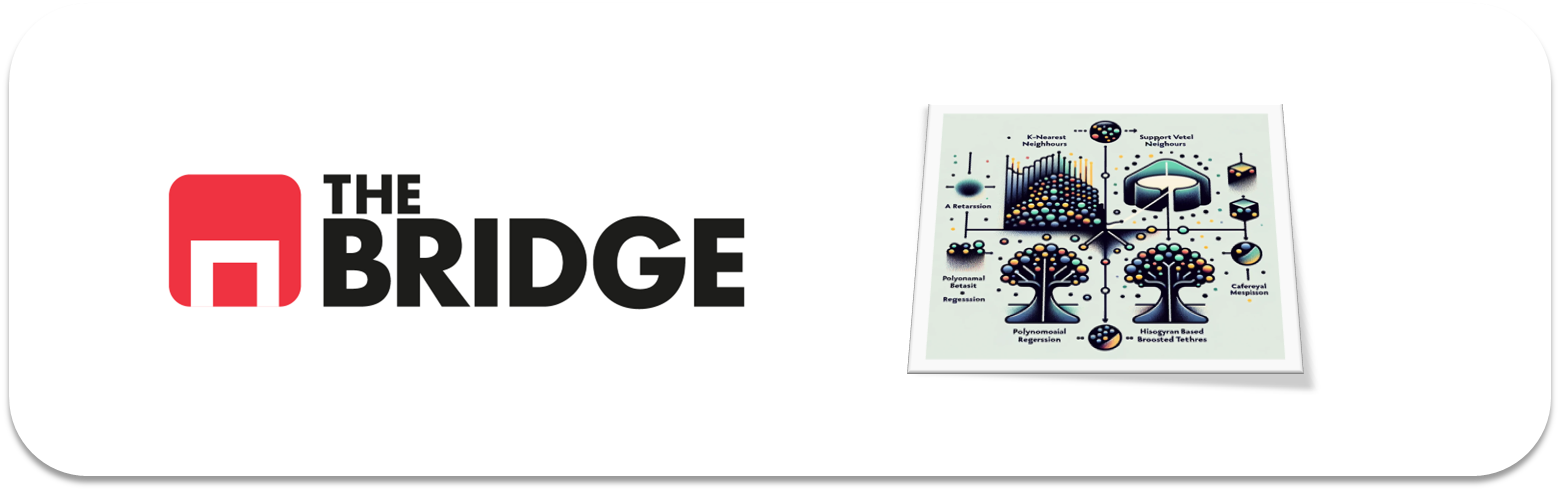

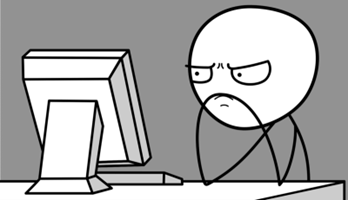

Para hacer un **repaso a los problemas de regresión con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Evaluación contra test.  
10. Análisis de errores, posibles acciones futuras.  
11. EXTRA: Persistencia del modelo en disco.  

### El problema de Negocio

El ayuntamiento de Freehold, Nueva Jersey, está preocupado por los niveles de Ozono en situaciones de contaminación. Ha adquirido unos sensores muy potentes que permiten medir la composición de la calidad del aire casi en tiempo real, pero desgraciadamente la medida de Ozono se obtiene mucho más tarde (casi 12 horas después, este dato de las horas no es relevante para el problema). Las medidas son enviadas a una plataforma central donde se quiere incorporar un modelo que en función de esas medidas pueda predecir el nivel de $O_3$ (Ozono) en el aire y establecer alarmas y umbrales para avisar a la población o tomar medidas si es necesaria.

El concejal de urbanismo y tecnología, Bruce S., os contrata para que creéis ese modelo y para ello os suministra un dataset con medidas de la calidad de aire donde han incorporado el nivel de Ozono ("PT08.S5(O3)") posteriormente. Quieren un modelo que se equivoque en media en menos de 100 unidades por millón (la medida en la que tienen registrada la presencia de Ozono).

¡Manos a la obra!

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV



### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué métricas creess más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

Se trata de un problema de regresión, ya que el objetivo es predecir un valor continuo correspondiente al nivel de Ozono. Dado que el requisito del negocio es que el modelo se equivoque en media en menos de 100 unidades, la métrica más adecuada para evaluar el rendimiento del modelo es el MAE. Como métricas complementarias, pueden emplearse el RMSE, para penalizar errores grandes, y el MAPE para analizar el error relativo.

### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [3]:
df = pd.read_csv("./data/air_contamination.csv")
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [8]:
target = "PT08.S5(O3)"	

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       8991 non-null   int64  
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        8991 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        8991 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 913.3 KB


In [5]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,-34.897053,1099.707856,-158.702591,10.082993,939.029205,163.732788,835.370973,56.654087,1456.143486,1022.780725,18.316054,49.232360,1.025530
std,78.202259,217.084571,140.680200,7.449640,266.829000,252.081877,256.815106,126.902274,346.204540,398.480897,8.832888,17.316389,0.403813
min,-200.000000,647.250000,-200.000000,0.149048,383.250000,-200.000000,322.000000,-200.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,0.600000,936.750000,-200.000000,4.436942,734.375000,49.000000,657.875000,52.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.500000,1063.000000,-200.000000,8.239851,909.000000,139.800000,805.500000,96.000000,1462.750000,963.250000,17.750000,49.550000,0.995395
75%,2.600000,1231.250000,-200.000000,13.988478,1116.250000,280.000000,969.250000,132.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701
max,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,332.600000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [14]:
for col in df.columns:
    print(df[col].value_counts(normalize=True).head())


CO(GT)
-200.0    0.183183
 1.0      0.031921
 1.4      0.029919
 1.5      0.029474
 1.6      0.029363
Name: proportion, dtype: float64
PT08.S1(CO)
1099.50    0.001335
954.25     0.001335
986.75     0.001335
1009.25    0.001223
988.25     0.001223
Name: proportion, dtype: float64
NMHC(GT)
-200    0.901346
 66     0.001446
 29     0.001001
 40     0.001001
 93     0.000890
Name: proportion, dtype: float64
C6H6(GT)
6.849892     0.001446
4.045717     0.001001
5.560496     0.001001
10.184263    0.001001
6.810175     0.001001
Name: proportion, dtype: float64
PT08.S2(NMHC)
850.25    0.001446
713.25    0.001001
791.00    0.001001
984.50    0.001001
848.50    0.001001
Name: proportion, dtype: float64
NOx(GT)
-200.0    0.177400
 65.0     0.003893
 89.0     0.003893
 41.0     0.003782
 57.0     0.003559
Name: proportion, dtype: float64
PT08.S3(NOx)
829.50    0.001223
866.25    0.001112
683.25    0.001112
767.00    0.001001
793.00    0.001001
Name: proportion, dtype: float64
NO2(GT)
-200.0    0.17

In [12]:
df.nunique().sort_values()

CO(GT)             95
NMHC(GT)          428
NO2(GT)          1367
NOx(GT)          2362
PT08.S1(CO)      3245
T                3367
PT08.S3(NOx)     3518
C6H6(GT)         3772
PT08.S2(NMHC)    3772
PT08.S4(NO2)     4407
PT08.S5(O3)      4678
RH               4902
AH               8987
dtype: int64

In [16]:
cols_with_missing = [
    "CO(GT)", "NOx(GT)", "NO2(GT)", "NMHC(GT)"
]

df[cols_with_missing] = df[cols_with_missing].replace(-200, np.nan)

df[cols_with_missing]

,CO(GT),NOx(GT),NO2(GT),NMHC(GT)
0,2.6,166.0,113.0,150.0
1,2.0,103.0,92.0,112.0
2,2.2,131.0,114.0,88.0
3,2.2,172.0,122.0,80.0
4,1.6,131.0,116.0,51.0
...,...,...,...,...
8986,3.1,471.7,189.8,NaN
8987,2.4,353.3,179.2,NaN
8988,2.4,293.0,174.7,NaN
8989,2.1,234.5,155.7,NaN


### Ejercicio 3: Split

Haz el split en train y test.

In [6]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 4: MiniEDA (I)

Analiza la distribución del target brevemente.

In [9]:
df[target].value_counts()

PT08.S5(O3)
825.75     10
1049.75     8
835.50      8
904.50      8
1023.50     8
           ..
650.50      1
1133.50     1
449.75      1
455.50      1
418.25      1
Name: count, Length: 4678, dtype: int64

<Axes: >

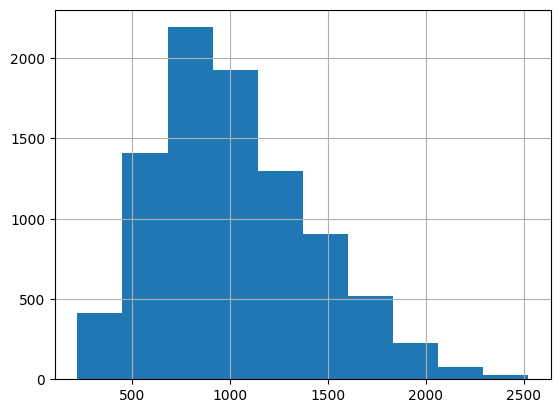

In [10]:
df[target].hist()

### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, para las numéricas analiza la correlación numéricamente y gráficamente, para las categóricas analiza la distribución del target para cada valor de la categórica.

In [ ]:
corr = train_set.corr()
corr_target = corr[target].abs().sort_values(ascending=False)
corr_target

PT08.S5(O3)      1.000000
PT08.S1(CO)      0.901005
PT08.S2(NMHC)    0.879959
C6H6(GT)         0.864269
PT08.S3(NOx)     0.794185
NOx(GT)          0.623100
PT08.S4(NO2)     0.590688
NO2(GT)          0.337581
RH               0.133955
CO(GT)           0.128110
NMHC(GT)         0.110077
AH               0.069113
T                0.032899
Name: PT08.S5(O3), dtype: float64

In [27]:
threshold = 0.3

selected_corr = corr_target[corr_target > threshold]
selected_corr

PT08.S5(O3)      1.000000
PT08.S1(CO)      0.901005
PT08.S2(NMHC)    0.879959
C6H6(GT)         0.864269
PT08.S3(NOx)     0.794185
NOx(GT)          0.623100
PT08.S4(NO2)     0.590688
NO2(GT)          0.337581
Name: PT08.S5(O3), dtype: float64

In [ ]:
selected_features = selected_corr.index.drop(target).tolist()
selected_features

['PT08.S1(CO)',
 'PT08.S2(NMHC)',
 'C6H6(GT)',
 'PT08.S3(NOx)',
 'NOx(GT)',
 'PT08.S4(NO2)',
 'NO2(GT)']

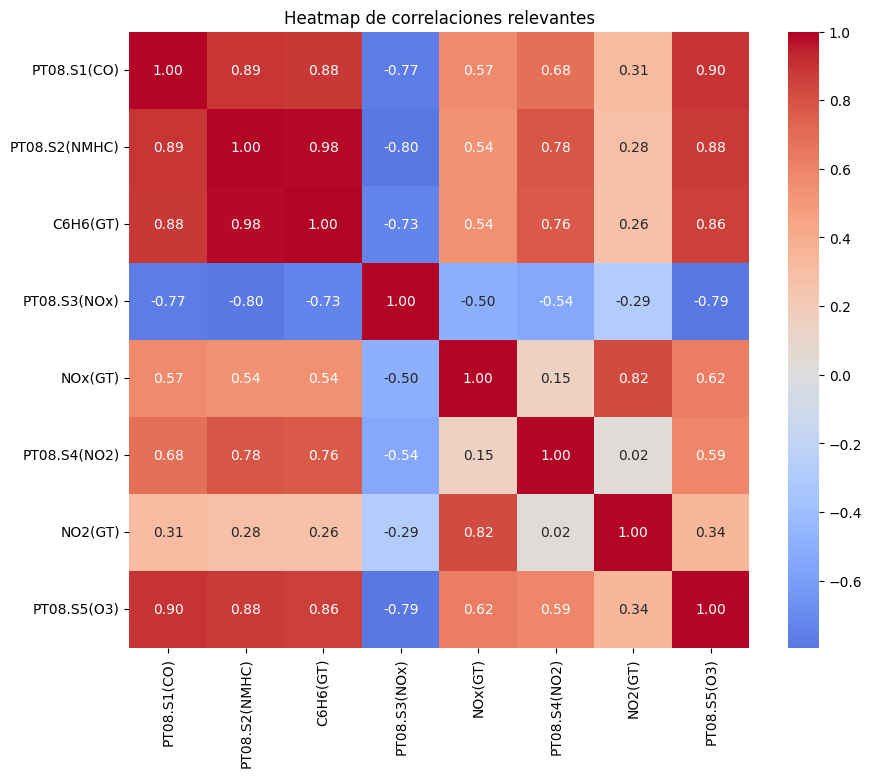

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr.loc[selected_features + [target], selected_features + [target]],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Heatmap de correlaciones relevantes")
plt.show()


In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

train_set[selected_features] = imputer.fit_transform(train_set[selected_features])
test_set[selected_features] = imputer.transform(test_set[selected_features])


### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [31]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import xgboost

xgb= xgboost.XGBRFRegressor(random_state=42)
gbr = GradientBoostingRegressor() 
rf = RandomForestRegressor()

model_list = {"XGBoost": xgb, 
              "Gradient Boosting": gbr,
              "Random Forest": rf}

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogite en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

Para el modelado se emplean algoritmos basados en ensembles, incluyendo Random Forest, Gradient Boosting y un Random Forest optimizado mediante XGBoost. Dado que estos modelos están basados en árboles, no requieren escalado de las variables, aunque sí es necesario tratar los valores faltantes previamente, ya que no admiten NaN en el entrenamiento.

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

In [32]:
X_train = train_set[selected_features]
X_test = test_set[selected_features]

y_train = train_set[target]
y_test = test_set[target]

### Ejercicios 9:

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. 

### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea "mean_absolute_error" (recuerda el funcionamiento del scoring en "sklearn", no te valdrá poner "mean_absolute_error"). Escoge el modelo ganador.

In [34]:
scores = {}

for name, modelo in model_list.items():
    cv_scores = cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_mean_absolute_error")
        
    scores[name] = -cv_scores.mean()

In [35]:
for model, score in scores.items():
    print(f"{model}: MAE medio = {score:.2f}")

best_model = min(scores, key=scores.get)
print("\nModelo ganador:", best_model)

XGBoost: MAE medio = 105.61
Gradient Boosting: MAE medio = 101.97
Random Forest: MAE medio = 93.76

Modelo ganador: Random Forest


### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinaciónde hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "mean absolute error". 

In [36]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

In [37]:
rf_base = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                              scoring="neg_mean_absolute_error", cv=5, n_jobs=-1, verbose=0)

grid_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [38]:
best_rf = grid_search_rf.best_estimator_

print("Mejores hiperparámetros:")
print(grid_search_rf.best_params_)

print("\nMejor MAE (CV):", -grid_search_rf.best_score_)

Mejores hiperparámetros:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Mejor MAE (CV): 94.45425621390153


### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE en test: {mae:.2f}")
print(f"RMSE en test: {rmse:.2f}")

MAE en test: 92.45
RMSE en test: 123.56


### Ejercicio 13: Análisis de errores

Comparar los valores predichos contra los reales mediante una gráfica (puedes emplear la función que empleamos en el workout de la unidad anterior). Haz un pequeño análisis.

In [44]:

def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()


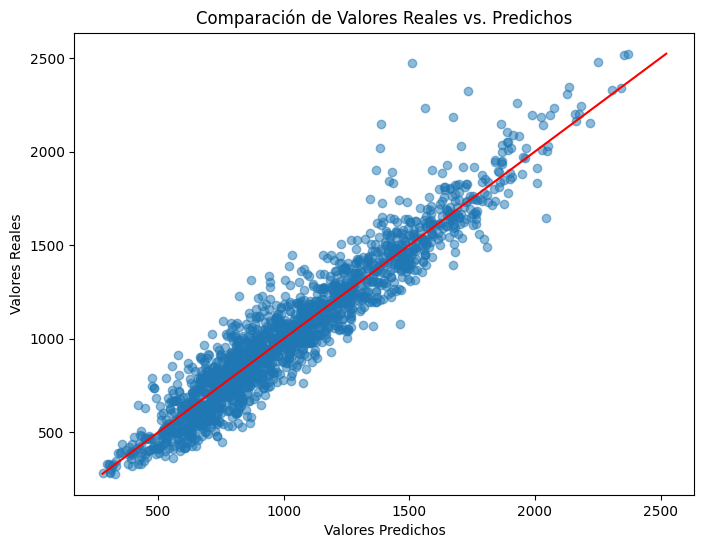

In [41]:
plot_predictions_vs_actual(y_test, y_pred)

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/o3_pred" con la extesión apropiada.

In [42]:
import joblib
import os

In [43]:
# crear carpeta si no existe
os.makedirs(".models", exist_ok=True)

# guardar el modelo
joblib.dump(best_rf, ".models/o3_pred.joblib")

['.models/o3_pred.joblib']